# New Jersey Digital Equity — Learn One Cell at a Time

**Read → run one cell → check its output → explain it in your own words.**
Use the play button beside a code cell, or press **Shift + Enter**. Run cells in
order. Later cells use variables created earlier. Choose a standard CPU runtime;
no GPU, subscription, or new resident survey is required.

This notebook uses a verified public-data snapshot: **ACS 2024 five-year estimates
(2020–2024)** and the **NJ Office of Broadband Connectivity asset directory**.
The main unit is a census tract. Directory records describe organizations and
reported services; they are not automatically verified service sites.

**Saved outputs were initially checked locally.** Running the cells in Colab
replaces those outputs with results from your own Colab runtime.

| Stage | What you will see |
|---|---|
| Setup and data | Package versions, downloaded ZIP, checksums, source log |
| Load and verify | Raw rows, geographic counts, missing values, passed checks |
| Define and describe | Variable meanings, denominator examples, summary tables |
| Visualize | Tract histogram, county comparison, poverty/access scatter plot |
| Check resources | Directory rows, duplicate/service/location flags, type chart |
| Save | CSV previews, findings, output ZIP and optional Google Drive copy |

**Keep definitions separate:** no internet access differs from no subscription.
A cellular-only subscription does not mean owning only a smartphone. Census
“computer” includes smartphones. Household adoption does not measure network
availability or government capacity. FCC availability data are not included.

## 1. Import the tools

`pandas` manages tables; `matplotlib` draws charts. Check the versions printed below.

**Checkpoint:** inspect the output before continuing.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, re, unicodedata, urllib.request, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown, FileLink
IN_COLAB = 'google.colab' in sys.modules or Path('/content').exists()
display(pd.DataFrame({'tool': ['Python', 'pandas', 'numpy', 'matplotlib'],
                      'version': [sys.version.split()[0], pd.__version__, np.__version__, matplotlib.__version__]}))

,tool,version
0,Python,3.12.14
1,pandas,2.2.3
2,numpy,2.3.5
3,matplotlib,3.11.2


## 2. Set the working folders

Colab keeps temporary files under `/content`. The final step can copy results to your Drive. The default input is the public GitHub snapshot; `drive` and `upload` are alternatives.

**Checkpoint:** inspect the output before continuing.

In [2]:
DATA_MODE = 'github'  # Choose 'github', 'drive', or 'upload'.
SNAPSHOT_URL = 'https://raw.githubusercontent.com/We1Chen7/nj-digital-equity/main/NJ_Digital_Equity_Data.zip'
EXPECTED_ZIP_SHA256 = 'caaafd135c4b0a77c488970cf876df858905ebab543e34d60fedc8876701e115'
ROOT = Path(os.environ.get('NJ_COLAB_ROOT', '/content/NJ_Digital_Equity' if IN_COLAB else '/tmp/NJ_Digital_Equity_Colab_Check'))
RAW, CLEAN, RESULTS = ROOT / 'data/raw', ROOT / 'data/processed', ROOT / 'results'
FIGURES = RESULTS / 'figures'
for folder in [ROOT, RAW, CLEAN, RESULTS, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
display(pd.DataFrame({'purpose': ['Input mode', 'Raw files', 'Processed CSVs', 'Results'],
                      'location': [DATA_MODE, str(RAW), str(CLEAN), str(RESULTS)]}))

,purpose,location
0,Input mode,github
1,Raw files,/tmp/NJ_Digital_Equity_Colab_Check/data/raw
2,Processed CSVs,/tmp/NJ_Digital_Equity_Colab_Check/data/processed
3,Results,/tmp/NJ_Digital_Equity_Colab_Check/results


## 3. Get the downloaded data

The ZIP contains the already downloaded official-source rows and metadata. Its checksum fixes the exact snapshot. Drive mode reads `MyDrive/NJ_Digital_Equity/NJ_Digital_Equity_Data.zip`; upload mode lets you select that ZIP from your computer. Drive mounting asks you to authorize access.

**Checkpoint:** inspect the output before continuing.

In [3]:
zip_path = ROOT / 'NJ_Digital_Equity_Data.zip'
local_check_bundle = os.environ.get('NJ_COLAB_BUNDLE')
if local_check_bundle:  # Used only for the local reproducibility check.
    shutil.copyfile(local_check_bundle, zip_path)
elif DATA_MODE == 'github':
    with urllib.request.urlopen(SNAPSHOT_URL, timeout=90) as response:
        zip_path.write_bytes(response.read())
elif DATA_MODE == 'drive':
    from google.colab import drive
    drive.mount('/content/drive')
    shutil.copyfile('/content/drive/MyDrive/NJ_Digital_Equity/NJ_Digital_Equity_Data.zip', zip_path)
elif DATA_MODE == 'upload':
    from google.colab import files
    uploaded = files.upload()
    assert 'NJ_Digital_Equity_Data.zip' in uploaded, 'Select the data ZIP.'
    zip_path.write_bytes(uploaded['NJ_Digital_Equity_Data.zip'])
else:
    raise ValueError('Choose github, drive, or upload.')
actual_sha = hashlib.sha256(zip_path.read_bytes()).hexdigest()
assert actual_sha == EXPECTED_ZIP_SHA256, 'Snapshot differs; stop and inspect the source.'
print('ZIP verified:', zip_path.name, '| bytes:', zip_path.stat().st_size)
print('SHA-256:', actual_sha)

ZIP verified: NJ_Digital_Equity_Data.zip | bytes: 907799
SHA-256: caaafd135c4b0a77c488970cf876df858905ebab543e34d60fedc8876701e115


## 4. Extract and inspect the files

A file inventory confirms that the data were extracted. File paths are checked before extraction.

**Checkpoint:** inspect the output before continuing.

In [4]:
with zipfile.ZipFile(zip_path) as archive:
    for member in archive.infolist():
        assert (ROOT / member.filename).resolve().is_relative_to(ROOT.resolve()), 'Unsafe ZIP path'
    archive.extractall(ROOT)
inventory = pd.DataFrame([{'file': str(p.relative_to(ROOT)), 'bytes': p.stat().st_size}
                          for p in sorted(RAW.glob('*')) if p.is_file()])
display(inventory)
print('Raw source files:', len(inventory))

,file,bytes
0,data/raw/B01002_metadata.json,202206
1,data/raw/B19013_metadata.json,200530
2,data/raw/B28002_metadata.json,217542
3,data/raw/B28003_metadata.json,206932
4,data/raw/C17002_metadata.json,209720
5,data/raw/download_manifest.json,5269
6,data/raw/nj_B01002.dat,106880
7,data/raw/nj_B19013.dat,74028
8,data/raw/nj_B28002.dat,245618
9,data/raw/nj_B28003.dat,142517


Raw source files: 15


## 5. Verify the raw files and their sources

The manifest records official URLs, collection dates and hashes. Every raw file must match its recorded checksum.

**Checkpoint:** inspect the output before continuing.

In [5]:
manifest = json.loads((RAW / 'download_manifest.json').read_text())
for filename, entry in manifest.items():
    actual = hashlib.sha256((RAW / filename).read_bytes()).hexdigest()
    assert actual == entry['saved_sha256'], 'File changed: ' + filename
source_log = pd.DataFrame([
    {'file': name, 'downloaded_utc': item['downloaded_utc'],
     'rows': item.get('retained_rows', item.get('rows')),
     'source_url': item['url']}
    for name, item in manifest.items()
])
display(source_log)
source_log.to_csv(RESULTS / 'source_log.csv', index=False)
print('PASS: every manifest file matches its checksum.')

,file,downloaded_utc,rows,source_url
0,nj_assets_metadata.json,2026-10-06T19:16:15.694702+00:00,NaN,https://data.nj.gov/api/views/yjm4-bujw.json
1,nj_assets_page_0.json,2026-10-06T19:16:16.229881+00:00,NaN,https://data.nj.gov/resource/yjm4-bujw.json?$l...
2,nj_assets_all.json,2026-10-07T16:53:18.209142+00:00,614.0,https://data.nj.gov/resource/yjm4-bujw.json
3,B28002_metadata.json,2026-10-06T19:16:16.426474+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...
4,nj_B28002.dat,2026-10-06T19:16:18.019458+00:00,2203.0,https://www2.census.gov/programs-surveys/acs/s...
5,B28003_metadata.json,2026-10-06T19:16:18.201611+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...
6,nj_B28003.dat,2026-10-06T19:16:27.761279+00:00,2203.0,https://www2.census.gov/programs-surveys/acs/s...
7,B19013_metadata.json,2026-10-06T19:16:27.947906+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...
8,nj_B19013.dat,2026-10-06T19:16:33.838150+00:00,2203.0,https://www2.census.gov/programs-surveys/acs/s...
9,C17002_metadata.json,2026-10-06T19:16:34.043654+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...


PASS: every manifest file matches its checksum.


## 6. Inspect the geographic identifiers

One raw row represents one Census geography. `GEO_ID` is the join key. We retain strings to preserve leading zeros.

**Checkpoint:** inspect the output before continuing.

In [6]:
TABLES = ['B28002', 'B28003', 'B19013', 'C17002', 'B01002']
geo = pd.read_csv(RAW / 'nj_geographies.txt', sep='|', dtype=str, keep_default_na=False)
data = geo[['GEO_ID', 'NAME', 'STATE', 'COUNTY', 'TRACT', 'SUMLEVEL']].copy()
assert data['GEO_ID'].is_unique
display(data.head())
display(data['SUMLEVEL'].value_counts().rename_axis('summary_level').reset_index(name='rows'))

,GEO_ID,NAME,STATE,COUNTY,TRACT,SUMLEVEL
0,0400000US34,New Jersey,34,,,040
1,0500000US34001,"Atlantic County, New Jersey",34,001,,050
2,0500000US34003,"Bergen County, New Jersey",34,003,,050
3,0500000US34005,"Burlington County, New Jersey",34,005,,050
4,0500000US34007,"Camden County, New Jersey",34,007,,050


,summary_level,rows
0,140,2181
1,050,21
2,040,1


## 7. Inspect a raw internet table

`E` columns contain estimates and `M` columns contain margins of error. Negative Census special codes must not be treated as ordinary numbers.

**Checkpoint:** inspect the output before continuing.

In [7]:
raw_example = pd.read_csv(RAW / 'nj_B28002.dat', sep='|', dtype=str)
display(raw_example[['GEO_ID', 'B28002_E001', 'B28002_E013', 'B28002_M013']].head())
print('Rows:', len(raw_example), '| Columns:', len(raw_example.columns))

,GEO_ID,B28002_E001,B28002_E013,B28002_M013
0,0400000US34,3507701,189079,4292
1,0500000US34001,109557,7155,792
2,0500000US34003,355127,13522,974
3,0500000US34005,177222,6585,615
4,0500000US34007,202540,11531,988


Rows: 2203 | Columns: 27


## 8. Clean special codes and join five tables

Each table must have unique keys and exactly the same geographies. A validated one-to-one join prevents accidental row multiplication. Raw files remain unchanged.

**Checkpoint:** inspect the output before continuing.

In [8]:
special_values = []
for table in TABLES:
    part = pd.read_csv(RAW / f'nj_{table}.dat', sep='|', dtype=str)
    assert part['GEO_ID'].is_unique
    assert set(part['GEO_ID']) == set(data['GEO_ID'])
    for col in part.columns[1:]:
        numeric = pd.to_numeric(part[col], errors='coerce')
        invalid = numeric.isna() | numeric.lt(0)
        special_values.append({'column': col, 'special_or_missing_rows': int(invalid.sum())})
        part[col] = numeric.mask(numeric.lt(0))
    data = data.merge(part, on='GEO_ID', how='left', validate='one_to_one')

display(data[['GEO_ID', 'NAME', 'B28002_E001', 'B19013_E001', 'C17002_E001']].head())
print('Joined rows:', len(data), '| Columns:', len(data.columns))

,GEO_ID,NAME,B28002_E001,B19013_E001,C17002_E001
0,0400000US34,New Jersey,3507701,103556.0,9180234
1,0500000US34001,"Atlantic County, New Jersey",109557,78050.0,270285
2,0500000US34003,"Bergen County, New Jersey",355127,124884.0,951352
3,0500000US34005,"Burlington County, New Jersey",177222,108111.0,457553
4,0500000US34007,"Camden County, New Jersey",202540,88755.0,521654


Joined rows: 2203 | Columns: 68


## 9. Separate tracts, counties and the state

County and state rows must not be mixed with tract rows in a regression or tract summary.

**Checkpoint:** inspect the output before continuing.

In [9]:
data['geoid'] = data['GEO_ID'].str.split('US').str[-1]
tract = data.loc[data['SUMLEVEL'].eq('140')].copy()
county = data.loc[data['SUMLEVEL'].eq('050')].copy()
state = data.loc[data['SUMLEVEL'].eq('040')].copy()
display(pd.DataFrame({'unit': ['tract', 'county', 'state'],
                      'rows': [len(tract), len(county), len(state)]}))
display(tract[['geoid', 'NAME', 'B28002_E001', 'B28002_E013']].head())
pd.DataFrame(special_values).to_csv(RESULTS / 'census_special_values.csv', index=False)

,unit,rows
0,tract,2181
1,county,21
2,state,1


,geoid,NAME,B28002_E001,B28002_E013
22,34001000100,"Census Tract 1, Atlantic County, New Jersey",813,78
23,34001000200,"Census Tract 2, Atlantic County, New Jersey",1457,355
24,34001000300,"Census Tract 3, Atlantic County, New Jersey",1474,206
25,34001000400,"Census Tract 4, Atlantic County, New Jersey",1584,144
26,34001000500,"Census Tract 5, Atlantic County, New Jersey",999,98


## 10. Review missing or special values

This table shows where Census special values or missing entries occurred. A missing value is not a zero.

**Checkpoint:** inspect the output before continuing.

In [10]:
special_review = pd.DataFrame(special_values)
display(special_review.query('special_or_missing_rows > 0').sort_values('special_or_missing_rows', ascending=False).head(15))
print('Household denominators equal to zero:', int(tract['B28002_E001'].eq(0).sum()))

,column,special_or_missing_rows
39,B19013_M001,72
38,B19013_E001,31
60,B01002_E003,18
61,B01002_M003,18
58,B01002_E002,14
59,B01002_M002,14
56,B01002_E001,11
57,B01002_M001,11


Household denominators equal to zero: 15


## 11. Check totals and denominators

The internet categories must add to the household total, and numerator counts must fall within their denominators. All checks must pass.

**Checkpoint:** inspect the output before continuing.

In [11]:
checks = []
def check(name, passed, detail):
    checks.append({'check': name, 'passed': bool(passed), 'detail': str(detail)})
check('21 county rows', len(county) == 21, len(county))
check('One state row', len(state) == 1, len(state))
check('Unique tract GEOIDs', tract['geoid'].is_unique, len(tract))
check('All rows belong to NJ', data['STATE'].eq('34').all(), 'State FIPS 34')
check('Household totals agree across internet and device tables',
      data['B28002_E001'].eq(data['B28003_E001']).all(), 'B28002 vs B28003')
check('Internet categories add to total',
      data['B28002_E002'].add(data['B28002_E012']).add(data['B28002_E013']).eq(data['B28002_E001']).all(),
      'Subscription + access without subscription + no access')
check('Device categories add to total',
      data['B28003_E002'].add(data['B28003_E006']).eq(data['B28003_E001']).all(),
      'Has a computer + no computer')
for field in ['B28002_E013', 'B28002_E006', 'B28002_E007', 'B28003_E006']:
    valid = data[field].notna() & data['B28002_E001'].notna()
    check(field + ' is within total households',
          data.loc[valid, field].between(0, data.loc[valid, 'B28002_E001']).all(),
          int(valid.sum()))
quality = pd.DataFrame(checks)
display(quality)
quality.to_csv(RESULTS / 'quality_checks.csv', index=False)
assert quality['passed'].all(), 'Investigate failed checks before using results.'
print('Tracts with zero households:', int(tract['B28002_E001'].eq(0).sum()))
print('Tract-to-state household sum difference:', tract['B28002_E001'].sum() - state['B28002_E001'].iloc[0])

,check,passed,detail
0,21 county rows,True,21
1,One state row,True,1
2,Unique tract GEOIDs,True,2181
3,All rows belong to NJ,True,State FIPS 34
4,Household totals agree across internet and dev...,True,B28002 vs B28003
5,Internet categories add to total,True,Subscription + access without subscription + n...
6,Device categories add to total,True,Has a computer + no computer
7,B28002_E013 is within total households,True,2203
8,B28002_E006 is within total households,True,2203
9,B28002_E007 is within total households,True,2203


Tracts with zero households: 15
Tract-to-state household sum difference: 0


## 12. Calculate indicators

A percentage is `100 × numerator / denominator`. Zero denominators become missing. Poverty uses a person denominator; internet access uses households. Upper-bound median incomes are flagged.

**Checkpoint:** inspect the output before continuing.

In [12]:
RATE_SPECS = {
    'no_internet_access_pct': ('B28002_E013', 'B28002_E001'),
    'cellular_only_subscription_pct': ('B28002_E006', 'B28002_E001'),
    'cable_fiber_dsl_subscription_pct': ('B28002_E007', 'B28002_E001'),
    'no_computing_device_pct': ('B28003_E006', 'B28003_E001'),
}
def add_indicators(frame):
    frame = frame.copy()
    frame['households'] = frame['B28002_E001']
    for name, (num, den) in RATE_SPECS.items():
        frame[name] = 100 * frame[num] / frame[den].where(frame[den] > 0)
    frame['no_internet_subscription_pct'] = 100 * (frame['B28002_E012'] + frame['B28002_E013']) / frame['households'].where(frame['households'] > 0)
    frame['poverty_pct'] = 100 * (frame['C17002_E002'] + frame['C17002_E003']) / frame['C17002_E001'].where(frame['C17002_E001'] > 0)
    frame['median_household_income_usd'] = frame['B19013_E001']
    frame['income_upper_bound_flag'] = frame['B19013_E001'].ge(250001)
    frame['median_age_years'] = frame['B01002_E001']
    return frame
tract, county, state = [add_indicators(frame) for frame in [tract, county, state]]

display(tract[['NAME', 'households', 'no_internet_access_pct', 'poverty_pct', 'median_household_income_usd']].head().round(2))
print('Tracts with a valid household denominator:', int(tract['households'].gt(0).sum()))

,NAME,households,no_internet_access_pct,poverty_pct,median_household_income_usd
22,"Census Tract 1, Atlantic County, New Jersey",813,9.59,20.25,56222.0
23,"Census Tract 2, Atlantic County, New Jersey",1457,24.37,20.74,42346.0
24,"Census Tract 3, Atlantic County, New Jersey",1474,13.98,28.27,52763.0
25,"Census Tract 4, Atlantic County, New Jersey",1584,9.09,30.43,50104.0
26,"Census Tract 5, Atlantic County, New Jersey",999,9.81,25.39,53378.0


Tracts with a valid household denominator: 2166


## 13. Read the variable dictionary

Source metadata supplies the original definitions. Count margins of error are retained; derived percentages do not yet have calculated confidence intervals.

**Checkpoint:** inspect the output before continuing.

In [13]:
dictionary_rows = []
for table in TABLES:
    metadata = json.loads((RAW / f'{table}_metadata.json').read_text())['variables']
    for col in data.columns:
        match = re.fullmatch(table + r'_([EM])([0-9]{3})', col)
        if match:
            api_name = f'{table}_{match.group(2)}{match.group(1)}'
            dictionary_rows.append({'variable': col, 'definition': metadata[api_name]['label'],
                                    'source': f'https://api.census.gov/data/2024/acs/acs5/groups/{table}.html'})
for name, (num, den) in RATE_SPECS.items():
    dictionary_rows.append({'variable': name, 'definition': f'100 * {num} / {den}; percentage points; denominator > 0', 'source': 'Derived from ACS'})
dictionary_rows += [
    {'variable': 'no_internet_subscription_pct', 'definition': '100 * (B28002_E012 + B28002_E013) / household total', 'source': 'Derived from ACS'},
    {'variable': 'poverty_pct', 'definition': '100 * (C17002_E002 + C17002_E003) / C17002_E001; income/poverty ratio below 1', 'source': 'Derived from ACS'},
    {'variable': 'median_household_income_usd', 'definition': 'B19013_E001; dollars adjusted to 2024; upper-bound values flagged', 'source': 'ACS B19013'},
    {'variable': 'income_upper_bound_flag', 'definition': 'Median income >= 250001; inspect reporting bound before modeling', 'source': 'ACS B19013'},
    {'variable': 'median_age_years', 'definition': 'B01002_E001; median age in years', 'source': 'ACS B01002'},
]
dictionary = pd.DataFrame(dictionary_rows)
dictionary.to_csv(CLEAN / 'variable_dictionary.csv', index=False)
display(dictionary.loc[dictionary['variable'].isin(RATE_SPECS)].reset_index(drop=True))

,variable,definition,source
0,no_internet_access_pct,100 * B28002_E013 / B28002_E001; percentage po...,Derived from ACS
1,cellular_only_subscription_pct,100 * B28002_E006 / B28002_E001; percentage po...,Derived from ACS
2,cable_fiber_dsl_subscription_pct,100 * B28002_E007 / B28002_E001; percentage po...,Derived from ACS
3,no_computing_device_pct,100 * B28003_E006 / B28003_E001; percentage po...,Derived from ACS


## 14. Check one percentage by hand

Compare the household numerator, denominator and calculated percentage for five tracts. This makes the calculation visible.

**Checkpoint:** inspect the output before continuing.

In [14]:
example = tract.loc[tract['households'].gt(0), ['NAME', 'B28002_E013', 'households', 'no_internet_access_pct']].head().copy()
example['manual_check_pct'] = 100 * example['B28002_E013'] / example['households']
assert np.allclose(example['manual_check_pct'], example['no_internet_access_pct'])
display(example.round(3))
print('PASS: the manual calculations match.')

,NAME,B28002_E013,households,no_internet_access_pct,manual_check_pct
22,"Census Tract 1, Atlantic County, New Jersey",78,813,9.594,9.594
23,"Census Tract 2, Atlantic County, New Jersey",355,1457,24.365,24.365
24,"Census Tract 3, Atlantic County, New Jersey",206,1474,13.976,13.976
25,"Census Tract 4, Atlantic County, New Jersey",144,1584,9.091,9.091
26,"Census Tract 5, Atlantic County, New Jersey",98,999,9.810,9.810


PASS: the manual calculations match.


## 15. Describe the tract data and statewide estimates

The tract summary weights each tract equally. Statewide percentages use the official state row and answer a different question.

**Checkpoint:** inspect the output before continuing.

In [15]:
METRICS = list(RATE_SPECS) + ['no_internet_subscription_pct', 'poverty_pct', 'median_household_income_usd', 'median_age_years']
desc = tract[METRICS].describe(percentiles=[.25, .5, .75]).T
desc['missing'] = tract[METRICS].isna().sum()
display(desc.round(2))
desc.to_csv(RESULTS / 'tract_descriptive_statistics.csv')
display(state[['NAME', 'households'] + list(RATE_SPECS)].round(2))

,count,mean,std,min,25%,50%,75%,max,missing
no_internet_access_pct,2166.0,5.61,6.45,0.0,1.81,3.88,7.31,100.00,15
cellular_only_subscription_pct,2166.0,10.58,5.91,0.0,6.42,9.38,13.42,42.19,15
cable_fiber_dsl_subscription_pct,2166.0,80.09,10.92,0.0,75.00,82.28,87.87,100.00,15
no_computing_device_pct,2166.0,4.22,5.04,0.0,1.32,3.01,5.62,100.00,15
no_internet_subscription_pct,2166.0,7.34,7.09,0.0,2.95,5.56,9.59,100.00,15
poverty_pct,2168.0,10.33,10.04,0.0,3.66,7.02,13.53,100.00,13
median_household_income_usd,2150.0,112053.34,50085.73,15943.0,75631.25,103495.00,139934.00,250001.00,31
median_age_years,2170.0,41.29,8.06,12.2,36.80,40.80,45.00,76.00,11


,NAME,households,no_internet_access_pct,cellular_only_subscription_pct,cable_fiber_dsl_subscription_pct,no_computing_device_pct
0,New Jersey,3507701,5.39,10.34,80.64,4.06


## 16. Inspect unusually high rates

Very small household denominators can produce extreme percentages. Review the count margin of error; do not interpret every extreme as a precise estimate.

**Checkpoint:** inspect the output before continuing.

In [16]:
extreme_rates = tract.nlargest(5, 'no_internet_access_pct')[
    ['NAME', 'households', 'B28002_E013', 'B28002_M013', 'no_internet_access_pct']]
display(extreme_rates.round(2))
extreme_rates.to_csv(RESULTS / 'extreme_rate_review.csv', index=False)

,NAME,households,B28002_E013,B28002_M013,no_internet_access_pct
2179,"Census Tract 9800, Union County, New Jersey",9,9,14,100.00
1685,"Census Tract 7154.03, Ocean County, New Jersey",739,574,148,77.67
1386,"Census Tract 9800, Middlesex County, New Jersey",17,13,21,76.47
1682,"Census Tract 7153.03, Ocean County, New Jersey",611,373,145,61.05
1683,"Census Tract 7153.04, Ocean County, New Jersey",1049,635,202,60.53


## 17. Chart the distribution across tracts

The histogram shows how many tracts fall into each percentage range. Each tract contributes once.

**Checkpoint:** inspect the output before continuing.

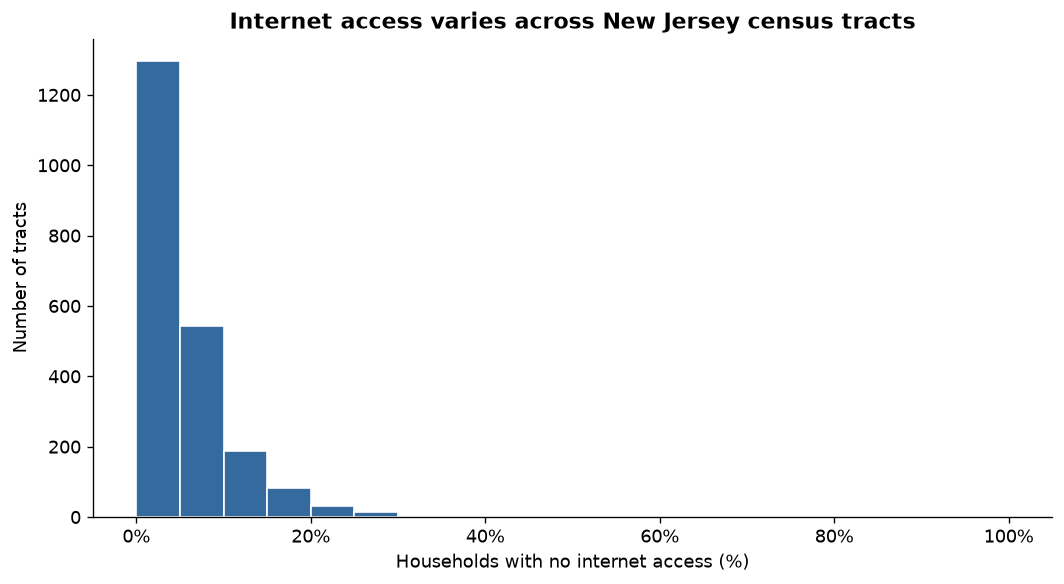

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tract['no_internet_access_pct'].dropna(), bins=np.arange(0, 101, 5), color='#346A9E', edgecolor='white')
ax.set(title='Internet access varies across New Jersey census tracts', xlabel='Households with no internet access (%)', ylabel='Number of tracts')
ax.xaxis.set_major_formatter(PercentFormatter(100))
fig.tight_layout(); fig.savefig(FIGURES / '01_tract_distribution.png', dpi=170); plt.show()

## 18. Compare the 21 counties

These bars show official county estimates. Ranking alone does not establish statistically significant differences.

**Checkpoint:** inspect the output before continuing.

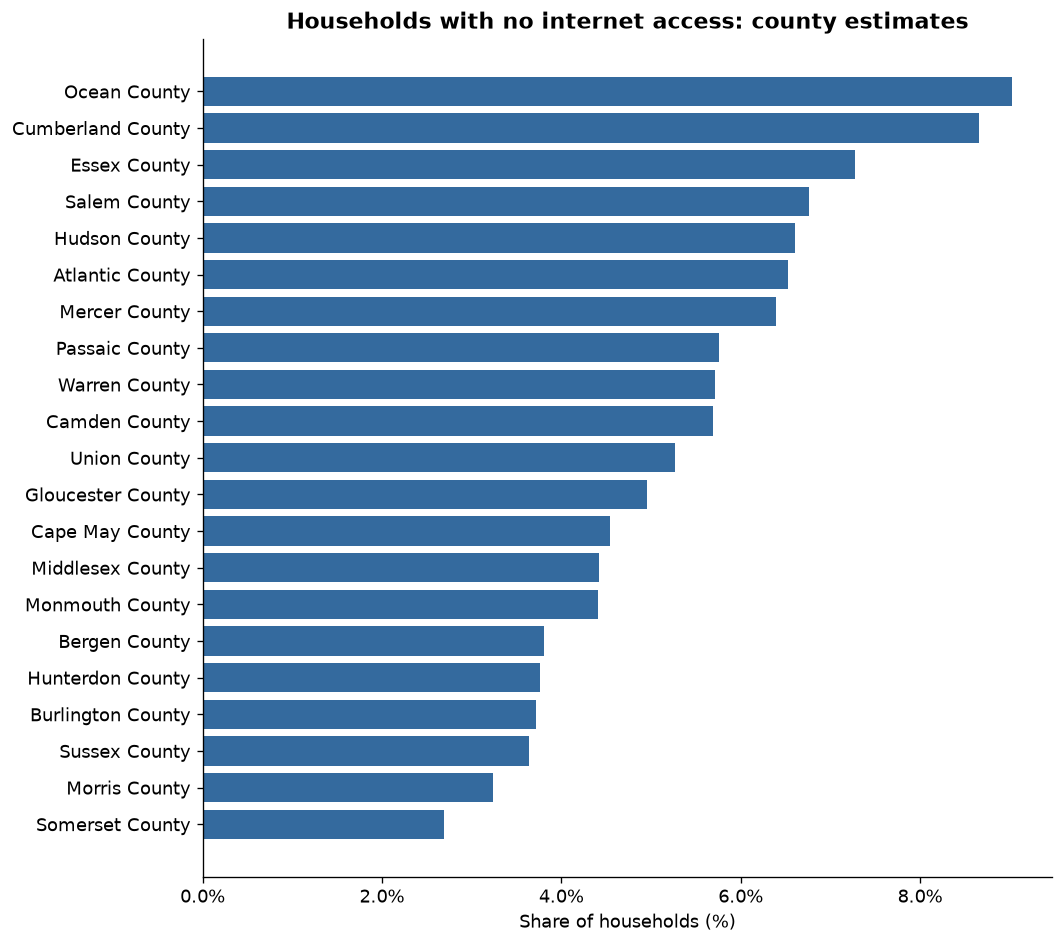

In [18]:
ranked = county.sort_values('no_internet_access_pct')
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(ranked['NAME'].str.replace(', New Jersey', '', regex=False), ranked['no_internet_access_pct'], color='#346A9E')
ax.set(title='Households with no internet access: county estimates', xlabel='Share of households (%)')
ax.xaxis.set_major_formatter(PercentFormatter(100))
fig.tight_layout(); fig.savefig(FIGURES / '02_county_comparison.png', dpi=170); plt.show()

## 19. Explore poverty and internet access

Each point is a tract. The correlation describes an ecological association; it cannot establish an individual relationship or causation.

**Checkpoint:** inspect the output before continuing.

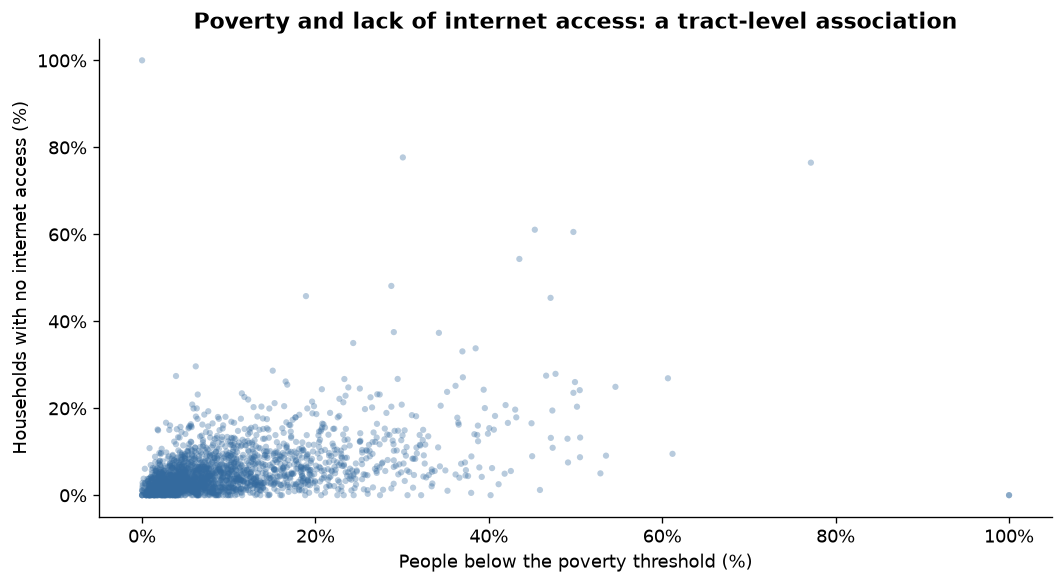

Unweighted tract Pearson correlation: 0.462; complete pairs: 2,166
This is a community-level association, not an individual or causal effect.


In [19]:
scatter = tract[['poverty_pct', 'no_internet_access_pct']].dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(scatter['poverty_pct'], scatter['no_internet_access_pct'], s=14, alpha=.35, color='#346A9E', edgecolors='none')
ax.set(title='Poverty and lack of internet access: a tract-level association', xlabel='People below the poverty threshold (%)', ylabel='Households with no internet access (%)')
ax.xaxis.set_major_formatter(PercentFormatter(100)); ax.yaxis.set_major_formatter(PercentFormatter(100))
fig.tight_layout(); fig.savefig(FIGURES / '03_poverty_and_access.png', dpi=170); plt.show()
correlation = scatter.corr().iloc[0, 1]
print(f'Unweighted tract Pearson correlation: {correlation:.3f}; complete pairs: {len(scatter):,}')
print('This is a community-level association, not an individual or causal effect.')

## 20. Open the organization directory

One row is a directory record. Review the organization name, type and reported service area before counting services.

**Checkpoint:** inspect the output before continuing.

In [20]:
source_assets = json.loads((RAW / 'nj_assets_all.json').read_text())
assets = pd.json_normalize(source_assets)

display(assets[['organization_name1', 'organization_type', 'geographic_service_area', 'city']].head(10))
print('Raw directory records:', len(assets))

,organization_name1,organization_type,geographic_service_area,city
0,XCHANGE TELECOM LLC,INTERNET SERVICE PROVIDER,OCEAN COUNTY,Brooklyn
1,THE HISPANIC FAMILY CENTER OF SOUTHERN NJ,LOCAL NONPROFIT,CAMDEN COUNTY,Camden and Woodbury
2,TDI CONNECT,LOCAL NONPROFIT,MERCER COUNTY,Hamilton
3,BOROUGH OF ROSELLE,LOCAL GOVERNMENT,UNION COUNTY,Roselle
4,HOPES CAP INC,LOCAL NONPROFIT,HUDSON COUNTY,Hoboken
5,NJCEDV,LOCAL NONPROFIT,STATEWIDE,Hamilton
6,GROTTA FUND FOR OLDER ADULTS,FOUNDATION/PHILANTHROPIC,MORRIS COUNTY,Whippany
7,"MFA, INC",LOCAL NONPROFIT,SERVICE EXTENT IS LIMITED TO MUNICIPALITY LEVEL.,Blairstown
8,"ATTOBAHN, INC",PRIVATE SECTOR,ESSEX COUNTY,Montclair
9,NJ TRANSIT,STATE GOVERNMENT,STATEWIDE,Newark


Raw directory records: 614


## 21. Flag duplicate names and service descriptions

Flags identify repeated name/address groups and selected wording. Text flags do not verify program capacity. Records explicitly stating no direct program stay visible.

**Checkpoint:** inspect the output before continuing.

In [21]:
def normalize(value):
    if pd.isna(value): return ''
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', str(value))).strip().upper()
for col in ['organization_name1', 'street_address', 'city', 'zip_code', 'cover_population_s', 'area_focus', 'geographic_service_area']:
    if col not in assets: assets[col] = ''
    assets[col + '_normalized'] = assets[col].map(normalize)
assets['record_number'] = np.arange(1, len(assets) + 1)
dup_keys = ['organization_name1_normalized', 'street_address_normalized', 'city_normalized', 'zip_code_normalized']
assets['duplicate_name_address_flag'] = assets.duplicated(dup_keys, keep=False)
assets['explicit_no_direct_program_flag'] = assets['cover_population_s_normalized'].str.contains('NO SPECIFIC/DIRECT DIGITAL INCLUSION PROGRAM', regex=False)
assets['digital_literacy_text_flag'] = assets['area_focus_normalized'].str.contains('DIGITAL LITERACY', regex=False)
assets['statewide_service_text_flag'] = assets['geographic_service_area_normalized'].str.replace('-', '', regex=False).str.contains('STATEWIDE', regex=False)

display(assets[['organization_name1', 'duplicate_name_address_flag', 'explicit_no_direct_program_flag', 'digital_literacy_text_flag', 'statewide_service_text_flag']].head(10))
print('Records explicitly reporting no direct program:', int(assets['explicit_no_direct_program_flag'].sum()))

,organization_name1,duplicate_name_address_flag,explicit_no_direct_program_flag,digital_literacy_text_flag,statewide_service_text_flag
0,XCHANGE TELECOM LLC,False,False,False,False
1,THE HISPANIC FAMILY CENTER OF SOUTHERN NJ,False,False,False,False
2,TDI CONNECT,False,False,False,False
3,BOROUGH OF ROSELLE,False,False,False,False
4,HOPES CAP INC,False,False,False,False
5,NJCEDV,False,False,False,True
6,GROTTA FUND FOR OLDER ADULTS,False,False,False,False
7,"MFA, INC",False,False,False,False
8,"ATTOBAHN, INC",False,False,False,False
9,NJ TRANSIT,False,False,False,True


Records explicitly reporting no direct program: 99


## 22. Check recorded locations

The approximate NJ bounding box is only a screening tool. An out-of-state office may serve NJ residents. An office location does not establish its service area.

**Checkpoint:** inspect the output before continuing.

In [22]:
coordinates = [entry.get('geocode', {}).get('coordinates', []) for entry in source_assets]
assets['longitude'] = [point[0] if len(point) == 2 else np.nan for point in coordinates]
assets['latitude'] = [point[1] if len(point) == 2 else np.nan for point in coordinates]
assets['coordinate_missing_flag'] = assets[['longitude', 'latitude']].isna().any(axis=1)
assets['outside_nj_bounding_box_flag'] = (~assets['coordinate_missing_flag']) & ~(assets['longitude'].between(-75.60, -73.85) & assets['latitude'].between(38.90, 41.36))

display(assets.loc[assets['coordinate_missing_flag'] | assets['outside_nj_bounding_box_flag'],
                   ['organization_name1', 'city', 'geographic_service_area', 'longitude', 'latitude', 'coordinate_missing_flag', 'outside_nj_bounding_box_flag']].head(12))
print('Missing coordinates:', int(assets['coordinate_missing_flag'].sum()))

,organization_name1,city,geographic_service_area,longitude,latitude,coordinate_missing_flag,outside_nj_bounding_box_flag
124,BASS RIVER COMMUNITY LIBRARY,NaN,NaN,0.000000,0.000000,False,True
357,BLACK CHURCHES FOR DIGITAL EQUITY,NaN,NaN,-77.042322,38.906875,False,True
380,SALEM/CUMBERLAND COUNTY,Trenton,SALEM COUNTY,NaN,NaN,True,False
391,VETERANS LEADERSHIP COUNCIL,NaN,NaN,-87.636631,41.882608,False,True
408,BRIGHT SPRINGS RES CARE,Statewide,STATEWIDE,-85.583447,38.257485,False,True
472,HOUSING PRESERVATION INCORPORATED,NaN,STATEWIDE,-89.868295,35.110128,False,True
535,PROJECT FREEDOM,Statewide,STATEWIDE,0.000000,0.000000,False,True
581,TURNING POINT,Statewide,STATEWIDE,0.000000,0.000000,False,True
583,UI REHAB NEW JERSEY SERVICES,Statewide,STATEWIDE,0.000000,0.000000,False,True
599,Bordentown Library,Bordentown,BURLINGTON COUNTY;,NaN,NaN,True,False


Missing coordinates: 16


## 23. Summarize directory quality

Flag categories can overlap, so do not add their counts together. The directory cannot demonstrate that areas with no recorded organizations have no services.

**Checkpoint:** inspect the output before continuing.

In [23]:
asset_quality = pd.DataFrame([
    {'measure': 'Raw directory records', 'count': len(assets)},
    {'measure': 'Unique normalized organization names (not necessarily service sites)', 'count': assets['organization_name1_normalized'].nunique()},
    {'measure': 'Records in repeated name/address groups (all members flagged)', 'count': int(assets['duplicate_name_address_flag'].sum())},
    {'measure': 'Missing coordinates', 'count': int(assets['coordinate_missing_flag'].sum())},
    {'measure': 'Coordinates outside approximate NJ bounding box', 'count': int(assets['outside_nj_bounding_box_flag'].sum())},
    {'measure': 'Text explicitly says no direct digital inclusion program', 'count': int(assets['explicit_no_direct_program_flag'].sum())},
    {'measure': 'Area-focus text mentions digital literacy', 'count': int(assets['digital_literacy_text_flag'].sum())},
    {'measure': 'Service-area text mentions statewide coverage', 'count': int(assets['statewide_service_text_flag'].sum())},
])
display(asset_quality)
asset_quality.to_csv(RESULTS / 'asset_quality_summary.csv', index=False)
display(assets[['organization_name1', 'organization_type', 'geographic_service_area', 'city', 'digital_literacy_text_flag', 'explicit_no_direct_program_flag']].head(10))
missing_assets = assets[[c for c in ['organization_name1', 'street_address', 'city', 'zip_code', 'geographic_service_area', 'area_focus'] if c in assets]].isna().sum().rename('missing_records').to_frame()
display(missing_assets)
missing_assets.to_csv(RESULTS / 'asset_field_missingness.csv')

,measure,count
0,Raw directory records,614
1,Unique normalized organization names (not nece...,606
2,Records in repeated name/address groups (all m...,2
3,Missing coordinates,16
4,Coordinates outside approximate NJ bounding box,8
5,Text explicitly says no direct digital inclusi...,99
6,Area-focus text mentions digital literacy,306
7,Service-area text mentions statewide coverage,112


,organization_name1,organization_type,geographic_service_area,city,digital_literacy_text_flag,explicit_no_direct_program_flag
0,XCHANGE TELECOM LLC,INTERNET SERVICE PROVIDER,OCEAN COUNTY,Brooklyn,False,False
1,THE HISPANIC FAMILY CENTER OF SOUTHERN NJ,LOCAL NONPROFIT,CAMDEN COUNTY,Camden and Woodbury,False,False
2,TDI CONNECT,LOCAL NONPROFIT,MERCER COUNTY,Hamilton,False,False
3,BOROUGH OF ROSELLE,LOCAL GOVERNMENT,UNION COUNTY,Roselle,False,False
4,HOPES CAP INC,LOCAL NONPROFIT,HUDSON COUNTY,Hoboken,False,False
5,NJCEDV,LOCAL NONPROFIT,STATEWIDE,Hamilton,False,False
6,GROTTA FUND FOR OLDER ADULTS,FOUNDATION/PHILANTHROPIC,MORRIS COUNTY,Whippany,False,False
7,"MFA, INC",LOCAL NONPROFIT,SERVICE EXTENT IS LIMITED TO MUNICIPALITY LEVEL.,Blairstown,False,False
8,"ATTOBAHN, INC",PRIVATE SECTOR,ESSEX COUNTY,Montclair,False,False
9,NJ TRANSIT,STATE GOVERNMENT,STATEWIDE,Newark,False,False


,missing_records
organization_name1,0
street_address,47
city,41
zip_code,63
geographic_service_area,18
area_focus,11


## 24. Chart the organization types

The chart counts directory records by reported organization type. It does not measure service effectiveness.

**Checkpoint:** inspect the output before continuing.

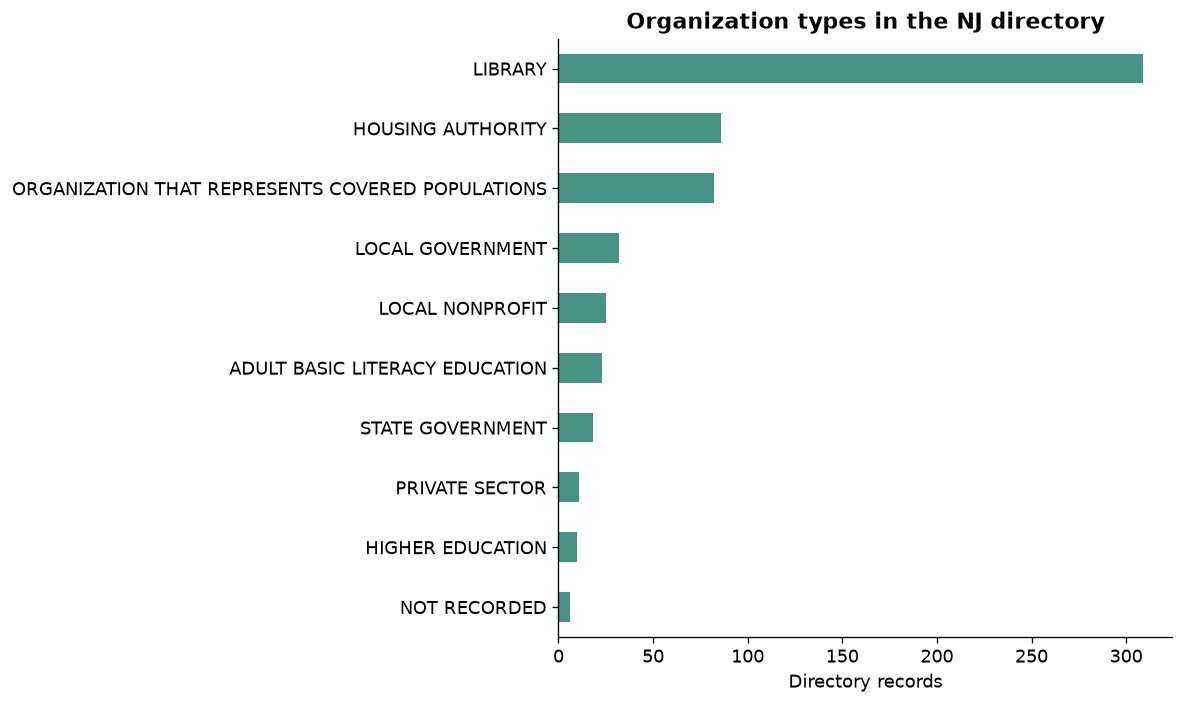

Directory rows last updated (UTC): 2025-05-23 17:16:43+00:00
Flags overlap. Do not add the flag counts together.


In [24]:
counts = assets['organization_type'].fillna('NOT RECORDED').map(normalize).value_counts()
counts.rename_axis('organization_type').reset_index(name='records').to_csv(RESULTS / 'asset_organization_types.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 6))
counts.head(10).sort_values().plot.barh(ax=ax, color='#479487')
ax.set(title='Organization types in the NJ directory', xlabel='Directory records', ylabel='')
fig.tight_layout(); fig.savefig(FIGURES / '04_resource_directory.png', dpi=170); plt.show()
asset_metadata = json.loads((RAW / 'nj_assets_metadata.json').read_text())
print('Directory rows last updated (UTC):', pd.to_datetime(asset_metadata['rowsUpdatedAt'], unit='s', utc=True))
print('Flags overlap. Do not add the flag counts together.')

## 25. Save the analysis and summarize the findings

Save clean tables, quality reports and a short findings note. Findings remain descriptive. No causal or infrastructure-availability model is produced.

**Checkpoint:** inspect the output before continuing.

In [25]:
tract.to_csv(CLEAN / 'nj_tract_digital_equity_2020_2024.csv', index=False)
county.to_csv(CLEAN / 'nj_county_digital_equity_2020_2024.csv', index=False)
state.to_csv(CLEAN / 'nj_state_digital_equity_2020_2024.csv', index=False)
# Raw records stay intact. The public analysis CSV omits contact-person details.
public_assets = assets.drop(columns=[c for c in assets if c.startswith(('contact_', 'geocode'))], errors='ignore')
public_assets.to_csv(CLEAN / 'nj_digital_inclusion_assets_flagged.csv', index=False)
acs_rate_cols = [c for c in tract if c.endswith('_pct')]
assert tract[acs_rate_cols].stack().between(0, 100).all()
source_status = pd.DataFrame([
    {'source': 'ACS 2024 five-year tables and geographies', 'status': 'Downloaded and verified', 'analysis_use': '2020-2024 community access conditions'},
    {'source': 'NJ OBC asset directory', 'status': 'Downloaded; quality limitations flagged', 'analysis_use': 'Directory description; spatial and service verification still required'},
    {'source': 'FCC National Broadband Map', 'status': 'Not downloaded; account/API access not configured', 'analysis_use': 'No infrastructure-availability variables in this dataset'},
])
source_status.to_csv(RESULTS / 'source_verification.csv', index=False)
display(source_status)
s = state.iloc[0]
findings = {
    'acs_period': '2020-2024', 'tracts': len(tract), 'counties': len(county),
    'tracts_with_positive_households': int(tract['households'].gt(0).sum()),
    'state_households': int(s['households']),
    'state_no_internet_access_pct': float(s['no_internet_access_pct']),
    'state_no_computing_device_pct': float(s['no_computing_device_pct']),
    'state_cellular_only_subscription_pct': float(s['cellular_only_subscription_pct']),
    'tract_poverty_access_correlation': float(correlation),
    'raw_asset_records': len(assets),
    'asset_quality': asset_quality.to_dict('records'),
}
(RESULTS / 'findings.json').write_text(json.dumps(findings, indent=2))
note = f"""# Initial descriptive findings

ACS period: 2020-2024. Tracts: {len(tract):,}; counties: {len(county)}.
Tracts with positive household denominators: {findings['tracts_with_positive_households']:,}.
State households (estimated): {findings['state_households']:,}.

Using the official state row, {s['no_internet_access_pct']:.2f}% of households
had no internet access, {s['no_computing_device_pct']:.2f}% had no computing device,
and {s['cellular_only_subscription_pct']:.2f}% had a cellular-only internet subscription.
The unweighted tract correlation between poverty and no internet access was
{correlation:.3f}. This is a descriptive ecological association, not causation.

The NJ resource directory contains {len(assets):,} raw records. Consult
asset_quality_summary.csv before counting service sites. Directory observations
are not capacity measurements, and a zero directory count would not establish
absence of services. Raw count margins of error are retained. Derived percentages
do not yet have calculated confidence intervals.

FCC availability was not downloaded. No resource-distance or causal model is
reported. The directory snapshot and ACS reference period differ.
"""
(RESULTS / 'INITIAL_FINDINGS.md').write_text(note)
display(Markdown(note))
print('Saved processed CSVs, quality tables, figures, source log and findings.')

,source,status,analysis_use
0,ACS 2024 five-year tables and geographies,Downloaded and verified,2020-2024 community access conditions
1,NJ OBC asset directory,Downloaded; quality limitations flagged,Directory description; spatial and service ver...
2,FCC National Broadband Map,Not downloaded; account/API access not configured,No infrastructure-availability variables in th...


# Initial descriptive findings

ACS period: 2020-2024. Tracts: 2,181; counties: 21.
Tracts with positive household denominators: 2,166.
State households (estimated): 3,507,701.

Using the official state row, 5.39% of households
had no internet access, 4.06% had no computing device,
and 10.34% had a cellular-only internet subscription.
The unweighted tract correlation between poverty and no internet access was
0.462. This is a descriptive ecological association, not causation.

The NJ resource directory contains 614 raw records. Consult
asset_quality_summary.csv before counting service sites. Directory observations
are not capacity measurements, and a zero directory count would not establish
absence of services. Raw count margins of error are retained. Derived percentages
do not yet have calculated confidence intervals.

FCC availability was not downloaded. No resource-distance or causal model is
reported. The directory snapshot and ACS reference period differ.


Saved processed CSVs, quality tables, figures, source log and findings.


## 26. Check the saved CSVs

Reopen the files to confirm their row counts and inspect the main tract CSV. Keep GEOIDs as strings when loading them elsewhere.

**Checkpoint:** inspect the output before continuing.

In [26]:
saved = []
for p in sorted(CLEAN.glob('*.csv')):
    check_frame = pd.read_csv(p, dtype={'geoid': str, 'GEO_ID': str})
    saved.append({'file': p.name, 'rows': len(check_frame), 'columns': len(check_frame.columns)})
display(pd.DataFrame(saved))
reopened = pd.read_csv(CLEAN / 'nj_tract_digital_equity_2020_2024.csv', dtype={'geoid': str})
assert len(reopened) == len(tract) and reopened['geoid'].is_unique
display(reopened[['geoid', 'NAME', 'households', 'no_internet_access_pct']].head().round(2))
print('PASS: saved tract keys and row count match.')

,file,rows,columns
0,nj_county_digital_equity_2020_2024.csv,21,79
1,nj_digital_inclusion_assets_flagged.csv,614,29
2,nj_state_digital_equity_2020_2024.csv,1,79
3,nj_tract_digital_equity_2020_2024.csv,2181,79
4,variable_dictionary.csv,71,3


,geoid,NAME,households,no_internet_access_pct
0,34001000100,"Census Tract 1, Atlantic County, New Jersey",813,9.59
1,34001000200,"Census Tract 2, Atlantic County, New Jersey",1457,24.37
2,34001000300,"Census Tract 3, Atlantic County, New Jersey",1474,13.98
3,34001000400,"Census Tract 4, Atlantic County, New Jersey",1584,9.09
4,34001000500,"Census Tract 5, Atlantic County, New Jersey",999,9.81


PASS: saved tract keys and row count match.


## 27. Package the results

This output ZIP contains processed CSVs, reports and PNG charts. It excludes the raw snapshot to avoid duplicating it. The next cell can save it to Drive.

**Checkpoint:** inspect the output before continuing.

In [27]:
OUTPUT_ZIP = ROOT / 'NJ_Digital_Equity_Results.zip'
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as archive:
    for folder in [CLEAN, RESULTS]:
        for p in sorted(folder.rglob('*')):
            if p.is_file():
                archive.write(p, p.relative_to(ROOT))
with zipfile.ZipFile(OUTPUT_ZIP) as archive:
    assert archive.testzip() is None
    display(pd.DataFrame([{'file': x.filename, 'bytes': x.file_size} for x in archive.infolist()]))
print('Results ZIP verified:', OUTPUT_ZIP.name)
display(FileLink(str(OUTPUT_ZIP)))

,file,bytes
0,data/processed/nj_county_digital_equity_2020_2...,11686
1,data/processed/nj_digital_inclusion_assets_fla...,265504
2,data/processed/nj_state_digital_equity_2020_20...,1561
3,data/processed/nj_tract_digital_equity_2020_20...,1014633
4,data/processed/variable_dictionary.csv,9406
5,results/INITIAL_FINDINGS.md,975
6,results/asset_field_missingness.csv,117
7,results/asset_organization_types.csv,393
8,results/asset_quality_summary.csv,406
9,results/census_special_values.csv,907


Results ZIP verified: NJ_Digital_Equity_Results.zip


/tmp/NJ_Digital_Equity_Colab_Check/NJ_Digital_Equity_Results.zip

## 28. Optionally save results to Google Drive

Set `SAVE_TO_DRIVE = True` when you want to copy the results ZIP to the same Drive folder. The default skips account access. Colab mounting requires your Google authorization. To download to your computer instead, uncomment the last two lines.

**Checkpoint:** inspect the output before continuing.

In [28]:
SAVE_TO_DRIVE = False
if SAVE_TO_DRIVE:
    assert IN_COLAB, 'This option is for a Colab runtime.'
    from google.colab import drive
    drive.mount('/content/drive')
    destination = Path('/content/drive/MyDrive/NJ_Digital_Equity')
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(OUTPUT_ZIP, destination / OUTPUT_ZIP.name)
    print('Saved to Google Drive:', destination / OUTPUT_ZIP.name)
else:
    print('Drive copy skipped. Results ZIP is ready in the runtime Files panel.')
    print('Set SAVE_TO_DRIVE = True and rerun this cell to save it to Drive.')
# from google.colab import files
# files.download(str(OUTPUT_ZIP))

Drive copy skipped. Results ZIP is ready in the runtime Files panel.
Set SAVE_TO_DRIVE = True and rerun this cell to save it to Drive.


## Write three sentences in English

1. “The unit of analysis is …”
2. “The county comparison shows …”
3. “This result does not establish …”

**Next research decision:** verify program types, service areas and actual service
locations before creating resource-access measures. Align time periods, calculate
uncertainty, and define the theoretical outcome before choosing a regression.

## Official sources

- [ACS 2024 summary files](https://www.census.gov/programs-surveys/acs/data/summary-file.2024.html)
- [B28002 internet definitions](https://api.census.gov/data/2024/acs/acs5/groups/B28002.html)
- [B28003 device definitions](https://api.census.gov/data/2024/acs/acs5/groups/B28003.html)
- [NJ OBC directory](https://data.nj.gov/resource/yjm4-bujw.json)
- [NJ mapping hub](https://www.nj.gov/connect/resources/mapping/)

The exact source files and collection timestamps are listed in Step 5. To collect
a new snapshot, use `download_data.py` in a new dated project folder; preserve the
existing snapshot used in your paper.